<a href="https://colab.research.google.com/github/lessleyH/energy-reliability-systems-/blob/main/ERCOT_2025_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import requests
from bs4 import BeautifulSoup

import os
import zipfile

In [3]:
os.listdir('/content/drive/MyDrive/energy-reliability-systems/data')

['Native_Load_2026.zip', 'Native_Load_2025.zip']

In [4]:
zip_path = '/content/drive/MyDrive/energy-reliability-systems/data/Native_Load_2025.zip'

In [5]:
import zipfile
import os

extract_path = '/content/ercot_data'

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Files extracted!")
print(os.listdir(extract_path))

Files extracted!
['Native_Load_2025.xlsx']


In [6]:
import os

os.listdir('/content/ercot_data')

['Native_Load_2025.xlsx']

In [7]:


file_path = '/content/ercot_data/Native_Load_2025.xlsx'

df = pd.read_excel(file_path)

df.head()

,Hour Ending,COAST,EAST,FWEST,NORTH,NCENT,SOUTH,SCENT,WEST,ERCOT
0,01/01/2025 01:00,10538.553193,1545.465863,7090.619810,1388.565588,11964.866264,3012.769998,6447.297871,1235.721317,43223.859905
1,01/01/2025 02:00,10477.912860,1553.994477,7040.460607,1390.392647,12064.919506,2962.803597,6382.650858,1249.397659,43122.532212
2,01/01/2025 03:00,10363.015361,1534.575620,7028.741719,1390.634577,12040.262276,2981.433181,6320.119991,1259.729121,42918.511847
3,01/01/2025 04:00,10259.984795,1548.084385,6992.734978,1402.423965,12055.424000,2970.761172,6277.132219,1274.238069,42780.783583
4,01/01/2025 05:00,10332.692971,1585.772017,7026.066195,1425.900669,12307.605237,2975.631819,6298.522746,1301.043053,43253.234707


In [8]:
df['Hour Ending'] = df['Hour Ending'].str.replace('24:00', '00:00')
df['Hour Ending'] = df['Hour Ending'].str.replace(' DST', '')

df['Hour Ending'] = pd.to_datetime(df['Hour Ending'])

df.head()

,Hour Ending,COAST,EAST,FWEST,NORTH,NCENT,SOUTH,SCENT,WEST,ERCOT
0,2025-01-01 01:00:00,10538.553193,1545.465863,7090.619810,1388.565588,11964.866264,3012.769998,6447.297871,1235.721317,43223.859905
1,2025-01-01 02:00:00,10477.912860,1553.994477,7040.460607,1390.392647,12064.919506,2962.803597,6382.650858,1249.397659,43122.532212
2,2025-01-01 03:00:00,10363.015361,1534.575620,7028.741719,1390.634577,12040.262276,2981.433181,6320.119991,1259.729121,42918.511847
3,2025-01-01 04:00:00,10259.984795,1548.084385,6992.734978,1402.423965,12055.424000,2970.761172,6277.132219,1274.238069,42780.783583
4,2025-01-01 05:00:00,10332.692971,1585.772017,7026.066195,1425.900669,12307.605237,2975.631819,6298.522746,1301.043053,43253.234707


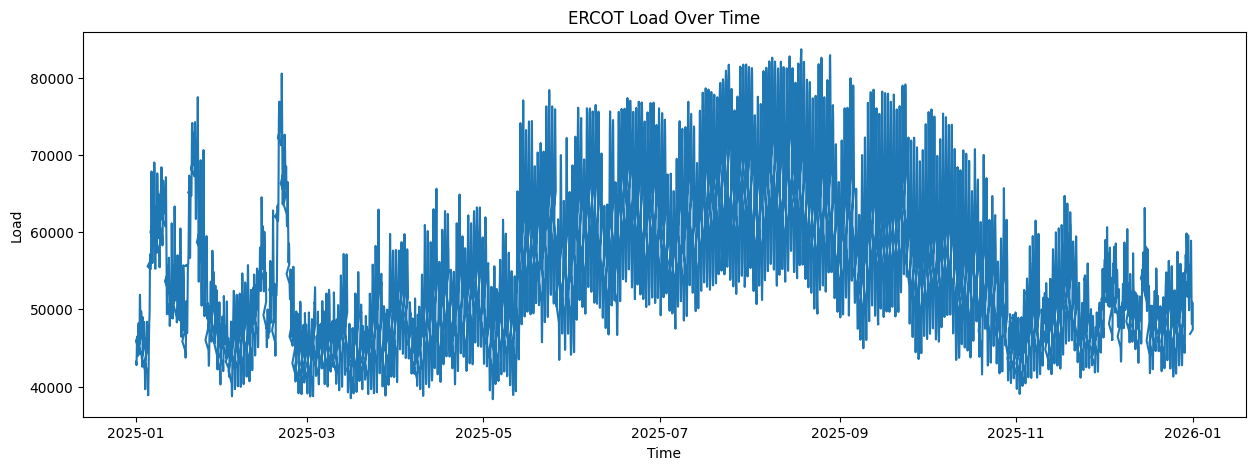

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(df['Hour Ending'], df['ERCOT'])

plt.title('ERCOT Load Over Time')
plt.xlabel('Time')
plt.ylabel('Load')

plt.show()

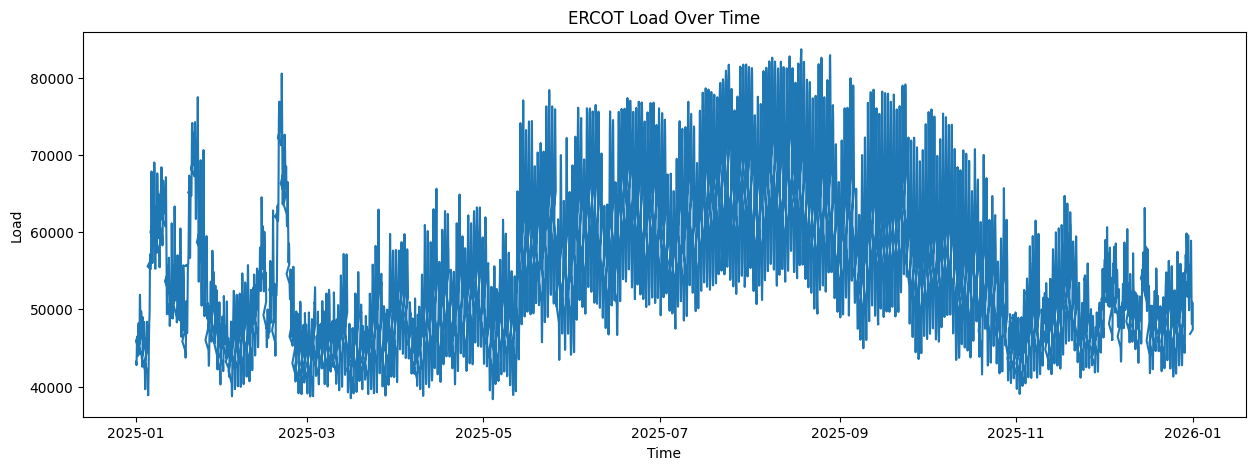

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(df['Hour Ending'], df['ERCOT'])

plt.title('ERCOT Load Over Time')
plt.xlabel('Time')
plt.ylabel('Load')

plt.show()

    Raw 2025 ERCOT load over time
    Shows seasonal behavior clearly: summer load is much higher and more volatile.

In [12]:
df.loc[df['ERCOT'].idxmax()]

,5512
Hour Ending,2025-08-18 18:00:00
COAST,22349.497921
EAST,2888.690723
FWEST,7046.24676
NORTH,1942.520791
NCENT,26581.624761
SOUTH,6508.846311
SCENT,14519.96276
WEST,1841.611669
ERCOT,83679.001697


    Max load moment
    Peak is Aug 18, 2025 at 6 PM around 83,679 MW — very summer/HVAC-driven.
    

In [14]:
df['Hour'] = df['Hour Ending'].dt.hour

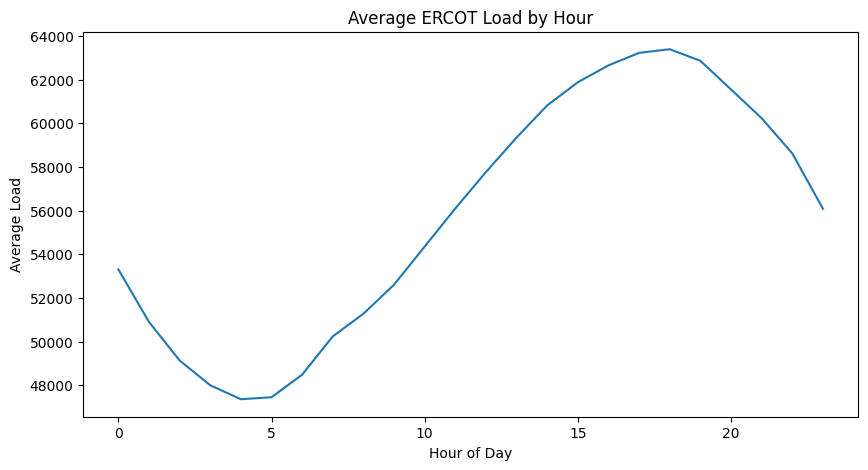

In [15]:
hourly_avg = df.groupby('Hour')['ERCOT'].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly_avg.index, hourly_avg.values)

plt.title('Average ERCOT Load by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Load')

plt.show()

    Average load by hour
    Nice smooth daily demand rhythm.

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Create date/month/season columns
df['Date'] = df['Hour Ending'].dt.date
df['Month'] = df['Hour Ending'].dt.month

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['Season'] = df['Month'].apply(get_season)

df[['Hour Ending', 'Hour', 'Month', 'Season', 'ERCOT']].head()

,Hour Ending,Hour,Month,Season,ERCOT
0,2025-01-01 01:00:00,1,1,Winter,43223.859905
1,2025-01-01 02:00:00,2,1,Winter,43122.532212
2,2025-01-01 03:00:00,3,1,Winter,42918.511847
3,2025-01-01 04:00:00,4,1,Winter,42780.783583
4,2025-01-01 05:00:00,5,1,Winter,43253.234707


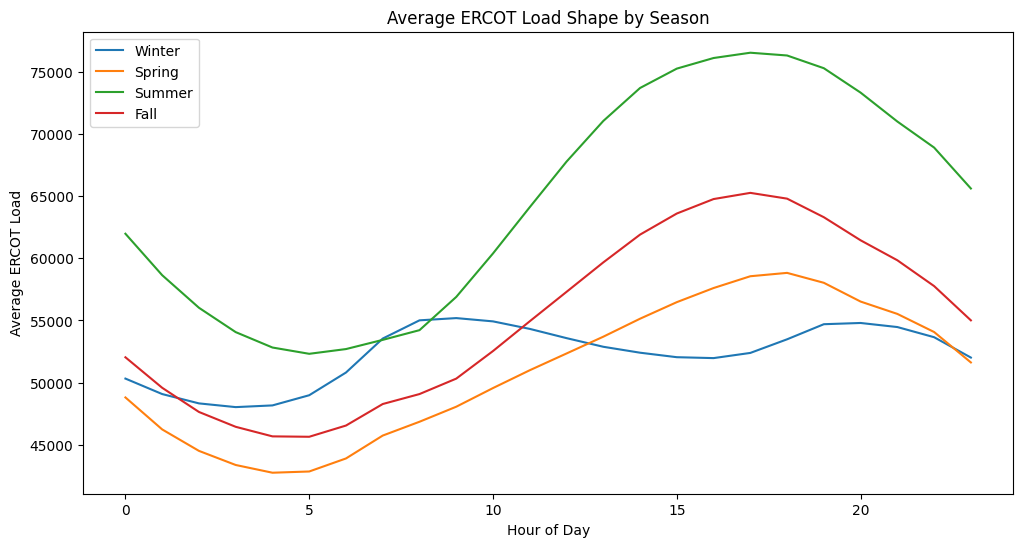

In [17]:
seasonal_hourly = (
    df.groupby(['Season', 'Hour'])['ERCOT']
    .mean()
    .reset_index()
)

season_order = ['Winter', 'Spring', 'Summer', 'Fall']

plt.figure(figsize=(12,6))

for season in season_order:
    subset = seasonal_hourly[seasonal_hourly['Season'] == season]
    plt.plot(subset['Hour'], subset['ERCOT'], label=season)

plt.title('Average ERCOT Load Shape by Season')
plt.xlabel('Hour of Day')
plt.ylabel('Average ERCOT Load')
plt.legend()
plt.show()

    shows winter behaves differently from summer/fall.

In [18]:
df = df.sort_values('Hour Ending')

df['Load_Change'] = df['ERCOT'].diff()
df['Abs_Load_Change'] = df['Load_Change'].abs()

df[['Hour Ending', 'ERCOT', 'Load_Change', 'Abs_Load_Change']].head()

,Hour Ending,ERCOT,Load_Change,Abs_Load_Change
23,2025-01-01 00:00:00,45875.362111,NaN,NaN
0,2025-01-01 01:00:00,43223.859905,-2651.502206,2651.502206
1,2025-01-01 02:00:00,43122.532212,-101.327693,101.327693
2,2025-01-01 03:00:00,42918.511847,-204.020365,204.020365
3,2025-01-01 04:00:00,42780.783583,-137.728264,137.728264


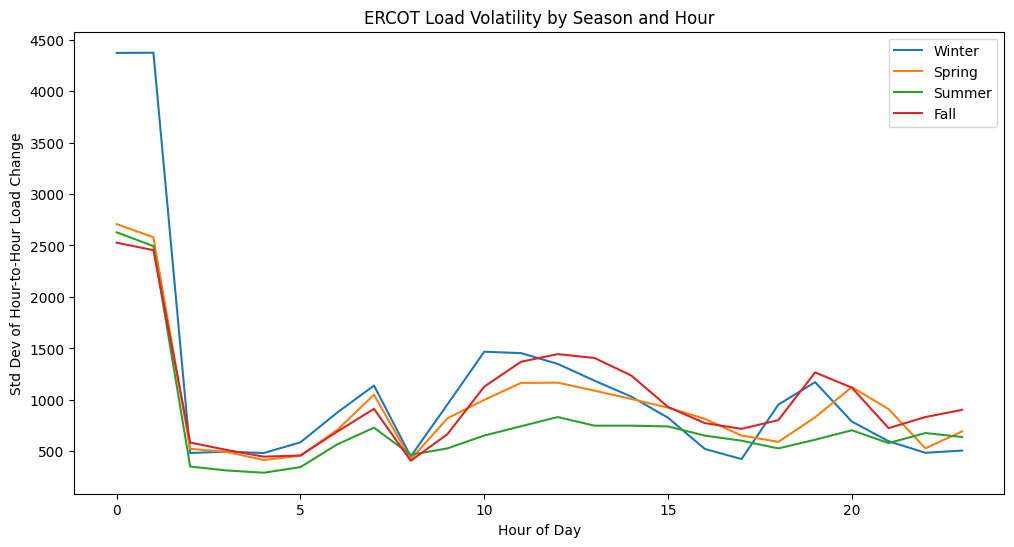

In [19]:
seasonal_volatility = (
    df.groupby(['Season', 'Hour'])['Load_Change']
    .std()
    .reset_index()
)

plt.figure(figsize=(12,6))

for season in season_order:
    subset = seasonal_volatility[seasonal_volatility['Season'] == season]
    plt.plot(subset['Hour'], subset['Load_Change'], label=season)

plt.title('ERCOT Load Volatility by Season and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Std Dev of Hour-to-Hour Load Change')
plt.legend()
plt.show()

In [21]:
daily_peak = df.groupby('Date')['ERCOT'].max()

stress_threshold = daily_peak.quantile(0.90)
print("Stress threshold:", stress_threshold)


stress_days = daily_peak[daily_peak >= stress_threshold].index

df['Day_Type'] = np.where(df['Date'].isin(stress_days), 'Stress', 'Normal')

df[['Hour Ending', 'Date', 'ERCOT', 'Day_Type']].head()

Stress threshold: 78507.1686474


,Hour Ending,Date,ERCOT,Day_Type
23,2025-01-01 00:00:00,2025-01-01,45875.362111,Normal
0,2025-01-01 01:00:00,2025-01-01,43223.859905,Normal
1,2025-01-01 02:00:00,2025-01-01,43122.532212,Normal
2,2025-01-01 03:00:00,2025-01-01,42918.511847,Normal
3,2025-01-01 04:00:00,2025-01-01,42780.783583,Normal


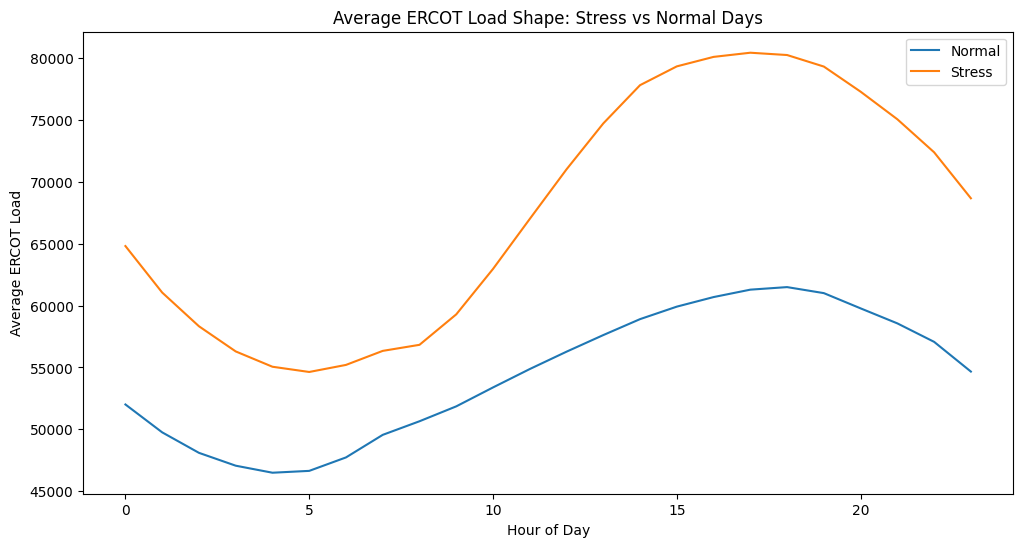

In [22]:
stress_hourly = (
    df.groupby(['Day_Type', 'Hour'])['ERCOT']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

for day_type in ['Normal', 'Stress']:
    subset = stress_hourly[stress_hourly['Day_Type'] == day_type]
    plt.plot(subset['Hour'], subset['ERCOT'], label=day_type)

plt.title('Average ERCOT Load Shape: Stress vs Normal Days')
plt.xlabel('Hour of Day')
plt.ylabel('Average ERCOT Load')
plt.legend()
plt.show()

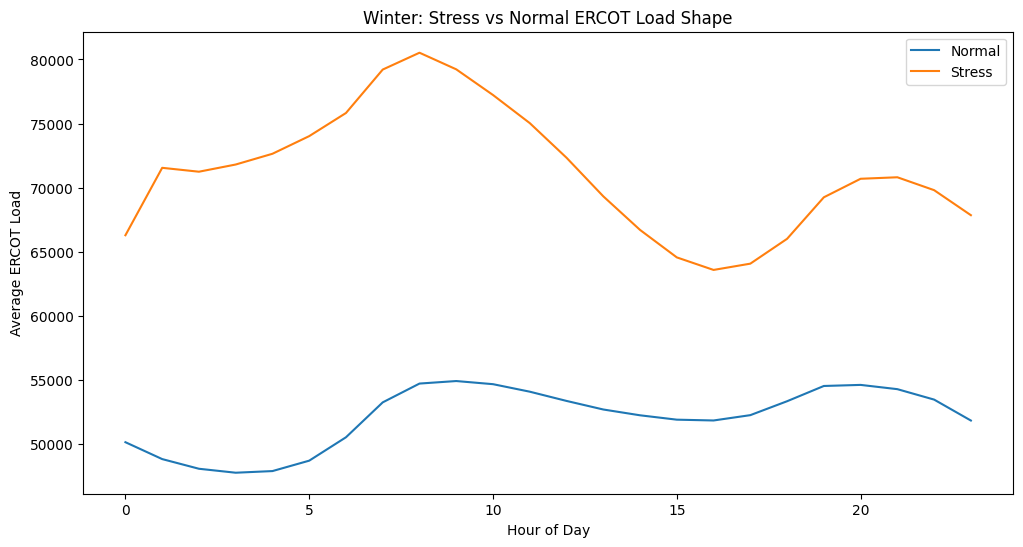

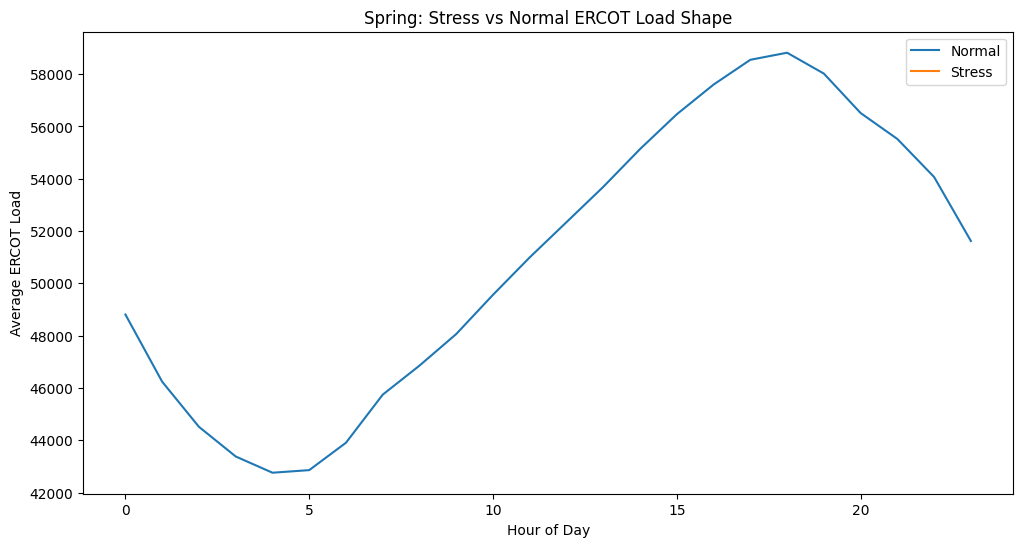

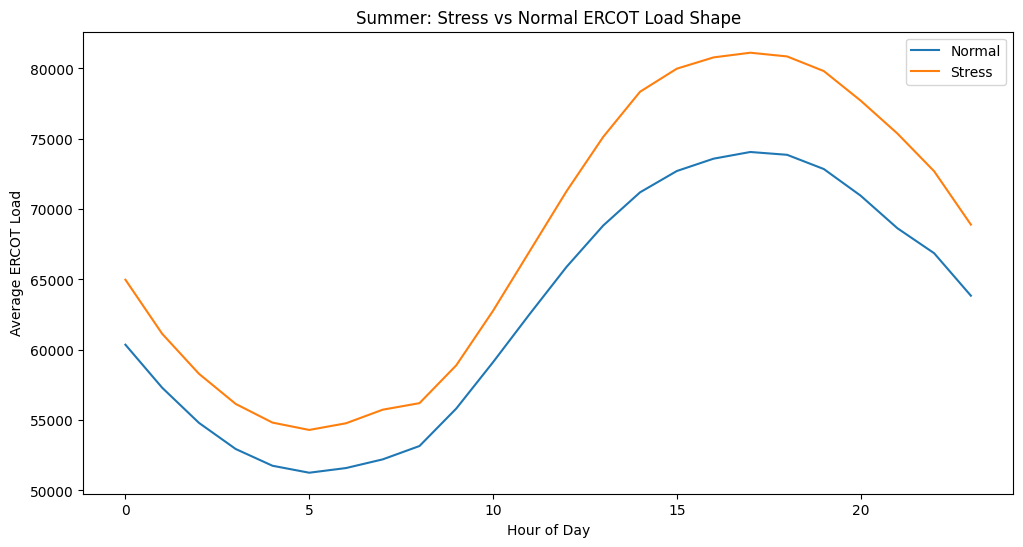

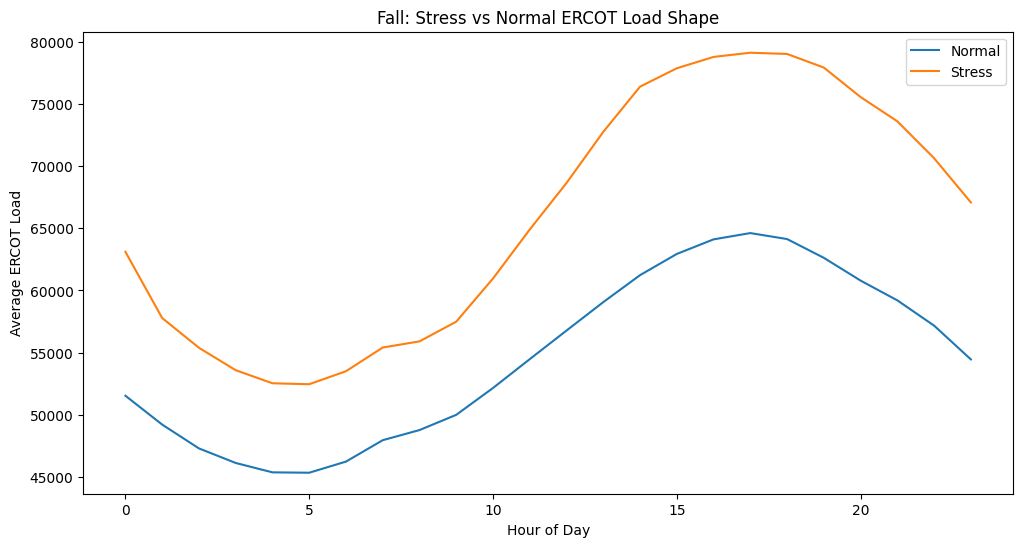

In [23]:
season_stress_hourly = (
    df.groupby(['Season', 'Day_Type', 'Hour'])['ERCOT']
    .mean()
    .reset_index()
)

for season in season_order:
    subset_season = season_stress_hourly[season_stress_hourly['Season'] == season]

    plt.figure(figsize=(12,6))

    for day_type in ['Normal', 'Stress']:
        subset = subset_season[subset_season['Day_Type'] == day_type]
        plt.plot(subset['Hour'], subset['ERCOT'], label=day_type)

    plt.title(f'{season}: Stress vs Normal ERCOT Load Shape')
    plt.xlabel('Hour of Day')
    plt.ylabel('Average ERCOT Load')
    plt.legend()
    plt.show()

In [24]:
# Define stress days within each season instead of across the whole year

daily = (
    df.groupby(['Date', 'Season'])['ERCOT']
    .max()
    .reset_index(name='Daily_Peak')
)

daily['Season_Stress_Threshold'] = daily.groupby('Season')['Daily_Peak'].transform(
    lambda x: x.quantile(0.90)
)

daily['Season_Day_Type'] = np.where(
    daily['Daily_Peak'] >= daily['Season_Stress_Threshold'],
    'Stress',
    'Normal'
)

df = df.merge(
    daily[['Date', 'Season_Day_Type']],
    on='Date',
    how='left'
)

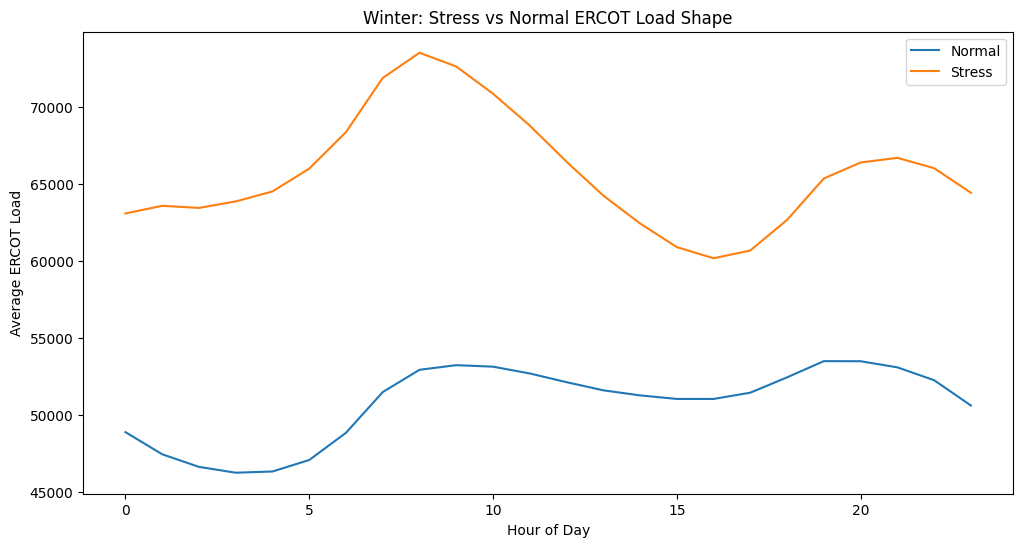

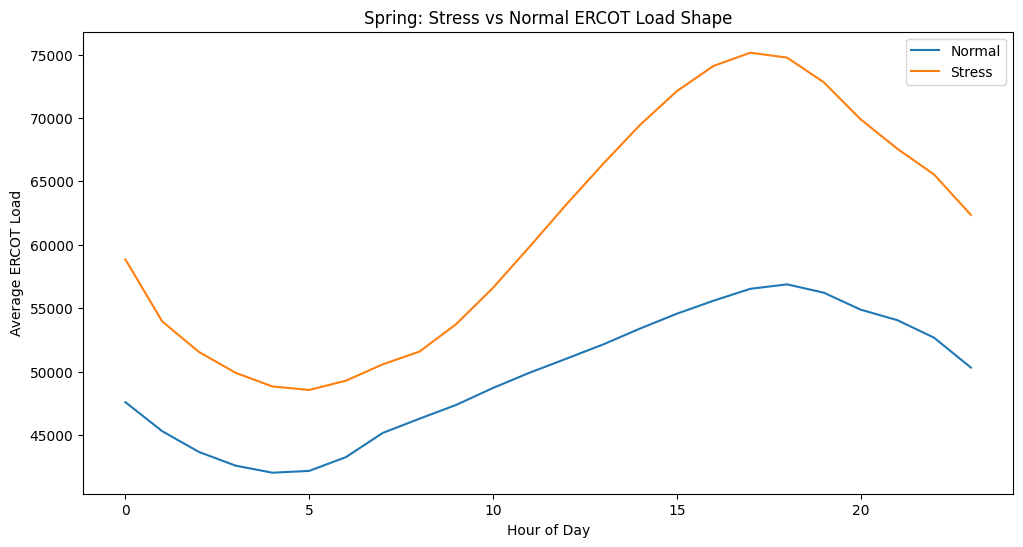

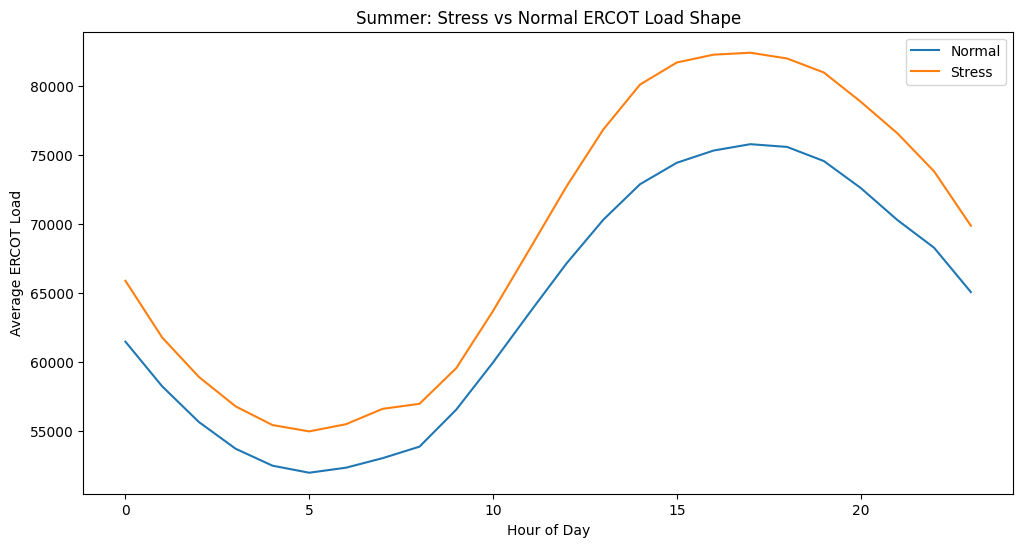

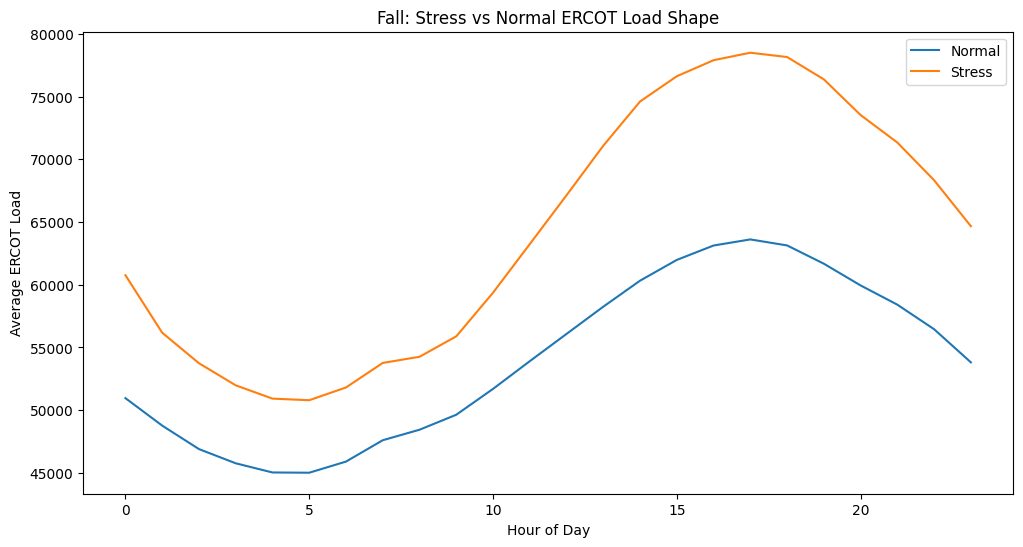

In [26]:
season_stress_hourly = (
    df.groupby(['Season', 'Season_Day_Type', 'Hour'])['ERCOT']
    .mean()
    .reset_index()
)

season_order = ['Winter', 'Spring', 'Summer', 'Fall']

for season in season_order:
    subset_season = season_stress_hourly[season_stress_hourly['Season'] == season]

    plt.figure(figsize=(12,6))

    for day_type in ['Normal', 'Stress']:
        subset = subset_season[subset_season['Season_Day_Type'] == day_type]
        plt.plot(subset['Hour'], subset['ERCOT'], label=day_type)

    plt.title(f'{season}: Stress vs Normal ERCOT Load Shape')
    plt.xlabel('Hour of Day')
    plt.ylabel('Average ERCOT Load')
    plt.legend()
    plt.show()

Winter ERCOT stress is driven by persistent heating demand and morning ramp behavior rather than solar/AC afternoon peaks.Winter ERCOT stress is driven by persistent heating demand and morning ramp behavior rather than solar/AC afternoon peaks.


ERCOT can absorb spring load growth more smoothly because weather volatility is lower.

Summer stress is not anomalous behavior.
It is amplification of normal ERCOT summer dynamics

Fall is intereting because its alomst behaving like a mini summer.